## Somerville Schools Traffic Analysis
### Phase 3-4: Analysis & Visualization

This notebook loads the processed data from Phase 1-2 and performs:
- Spatial joins (crashes to school buffers)
- Per-school crash statistics
- Traffic volume analysis near schools
- Final visualizations

In [185]:
# %pip install "leafmap[maplibre]" # Uncomment to install leafmap if needed

In [186]:
# Cell 1: Setup and imports
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import contextily as ctx
import os
import json
import ipywidgets as widgets
from ipyleaflet import Map, GeoJSON, GeoData, WidgetControl, basemaps


# Paths
data_processed = '../data/processed'
outputs = '../outputs'

In [187]:
# Cell 2: Load all datasets
crashes = gpd.read_file(os.path.join(data_processed, 'crashes_somerville_2023thru2025.geojson'))
schools = gpd.read_file(os.path.join(data_processed, 'somerville_schools_processed.geojson'))
traffic = gpd.read_file(os.path.join(data_processed, 'trafficvolume2024_somerville_processed.geojson'))
buffer_025 = gpd.read_file(os.path.join(data_processed, 'school_buffers_025mi.geojson'))
buffer_05 = gpd.read_file(os.path.join(data_processed, 'school_buffers_05mi.geojson'))
boundary = gpd.read_file(os.path.join(data_processed, 'somerville_boundary.geojson'))

In [188]:
# Cell 3: Quick CRS verification
print(f"Crashes CRS: {crashes.crs}")
print(f"Schools CRS: {schools.crs}")
print(f"Traffic CRS: {traffic.crs}")
print(f"Buffer 0.25mi CRS: {buffer_025.crs}")
print(f"Buffer 0.5mi CRS: {buffer_05.crs}")
print(f"Somerville CRS: {boundary.crs}")

Crashes CRS: EPSG:26986
Schools CRS: EPSG:26986
Traffic CRS: EPSG:26986
Buffer 0.25mi CRS: EPSG:26986
Buffer 0.5mi CRS: EPSG:26986
Somerville CRS: EPSG:26986


In [189]:
# Cell 4: INNER JOIN crashes to 0.25 mile school buffers to identify crashes within 0.25 miles of schools

crashes_in_025 = gpd.sjoin(
    crashes,
    buffer_025,
    how='inner',
    predicate='within'
)

print(f"✅ Found {len(crashes_in_025)} crashes within 0.25mi of schools")
print(f"   ({len(crashes_in_025)/len(crashes)*100:.1f}% of all crashes)")

# Show first few
print("\nSample crashes in school zones:")
print(crashes_in_025[['Crash_Number', 'Crash_Date', 'Crash_Severity', 'school_name']].head())
print("🔍 Identifying crashes within 0.25 miles of schools...")

✅ Found 509 crashes within 0.25mi of schools
   (29.6% of all crashes)

Sample crashes in school zones:
    Crash_Number   Crash_Date                       Crash_Severity  \
7        5223266  06-Jan-2023                     Non-fatal injury   
10       5223265  08-Jan-2023  Property damage only (none injured)   
11       5223268  08-Jan-2023                     Non-fatal injury   
13       5223273  09-Jan-2023                              Unknown   
21       5205084  13-Jan-2023                     Non-fatal injury   

                         school_name  
7        Albert F. Argenziano School  
10          Benjamin G. Brown School  
11          Benjamin G. Brown School  
13       Albert F. Argenziano School  
21  East Somerville Community School  
🔍 Identifying crashes within 0.25 miles of schools...


In [190]:
# Cell 5: Join crashes to 0.5 mile school buffers
print("🔍 Identifying crashes within 0.5 miles of schools...")

crashes_in_05 = gpd.sjoin(
    crashes,
    buffer_05,
    how='inner',
    predicate='within'
)

print(f"✅ Found {len(crashes_in_05)} crashes within 0.5mi of schools")
print(f"   ({len(crashes_in_05)/len(crashes)*100:.1f}% of all crashes)")

# Show increase
increase = len(crashes_in_05) - len(crashes_in_025)
print(f"\n📈 Expanding to 0.5mi captures {increase} additional crashes, compared to {len(crashes_in_025)} crashes found within 0.25mi radius.")

🔍 Identifying crashes within 0.5 miles of schools...
✅ Found 2382 crashes within 0.5mi of schools
   (138.3% of all crashes)

📈 Expanding to 0.5mi captures 1873 additional crashes, compared to 509 crashes found within 0.25mi radius.


In [191]:
crashes_in_025['Crash_Severity'].value_counts()

Crash_Severity
Property damage only (none injured)    328
Non-fatal injury                       165
Unknown                                 16
Name: count, dtype: int64

In [192]:
# Cell 6: Crash counts by school (0.25 mile buffer)
school_crash_counts_025mi = crashes_in_025.groupby('school_name').size().reset_index(name='crashes_025mi')
school_crash_counts_025mi = school_crash_counts_025mi.sort_values('crashes_025mi', ascending=False).reset_index(drop=True)

print("📊 CRASH COUNTS BY SCHOOL (within 0.25 miles)")
print("=" * 60)
print(school_crash_counts_025mi.to_string(index=False))

# Calculate summary stats
print(f"\n🔖 Summary:")
print(f"   Average crashes per school: {school_crash_counts_025mi['crashes_025mi'].mean():.1f}")
print(f"   Median crashes per school: {school_crash_counts_025mi['crashes_025mi'].median():.0f}")
print(f"   Highest: {school_crash_counts_025mi.iloc[0]['school_name']} ({school_crash_counts_025mi.iloc[0]['crashes_025mi']} crashes)")
print(f"   Lowest: {school_crash_counts_025mi.iloc[-1]['school_name']} ({school_crash_counts_025mi.iloc[-1]['crashes_025mi']} crashes)")
display(school_crash_counts_025mi)

📊 CRASH COUNTS BY SCHOOL (within 0.25 miles)
                            school_name  crashes_025mi
Winter Hill Community Innovation School            100
       East Somerville Community School             91
            Albert F. Argenziano School             80
                 Somerville High School             74
                Arthur D. Healey School             58
                 John F. Kennedy School             43
    West Somerville Neighborhood School             36
               Benjamin G. Brown School             27

🔖 Summary:
   Average crashes per school: 63.6
   Median crashes per school: 66
   Highest: Winter Hill Community Innovation School (100 crashes)
   Lowest: Benjamin G. Brown School (27 crashes)


,school_name,crashes_025mi
0,Winter Hill Community Innovation School,100
1,East Somerville Community School,91
2,Albert F. Argenziano School,80
3,Somerville High School,74
4,Arthur D. Healey School,58
5,John F. Kennedy School,43
6,West Somerville Neighborhood School,36
7,Benjamin G. Brown School,27


In [193]:
# Cell 7: Crash severity breakdown by school
if 'Crash_Severity' in crashes_in_025.columns:
    # Create pivot table
    severity_pivot_025mi = pd.crosstab(
        crashes_in_025['school_name'],
        crashes_in_025['Crash_Severity'],
        margins=True,
        margins_name='Total'
    )
    
    print("\n📊 CRASH SEVERITY BY SCHOOL (0.25 mile buffer)")
    print("=" * 70)
    print(severity_pivot_025mi)
    
    # Calculate injury crash percentage
    if 'Non-fatal injury' in severity_pivot_025mi.columns or 'Fatal injury' in severity_pivot_025mi.columns:
        injury_cols = [col for col in severity_pivot_025mi.columns if 'injury' in col.lower() or 'fatal' in col.lower()]
        if injury_cols:
            severity_pivot_025mi['injury_pct'] = (severity_pivot_025mi[injury_cols].sum(axis=1) / severity_pivot_025mi['Total']) * 100
            print("\n⚠️  Injury Crash Percentage:")
            print(severity_pivot_025mi[['Total'] + injury_cols + ['injury_pct']].round(1))


📊 CRASH SEVERITY BY SCHOOL (0.25 mile buffer)
Crash_Severity                           Non-fatal injury  \
school_name                                                 
Albert F. Argenziano School                            30   
Arthur D. Healey School                                15   
Benjamin G. Brown School                                7   
East Somerville Community School                       30   
John F. Kennedy School                                 18   
Somerville High School                                 25   
West Somerville Neighborhood School                     9   
Winter Hill Community Innovation School                31   
Total                                                 165   

Crash_Severity                           Property damage only (none injured)  \
school_name                                                                    
Albert F. Argenziano School                                               44   
Arthur D. Healey School                  

In [194]:
severity_pivot_025mi

Crash_Severity,Non-fatal injury,Property damage only (none injured),Unknown,Total,injury_pct
school_name,,,,,
Albert F. Argenziano School,30,44,6,80,37.500000
Arthur D. Healey School,15,39,4,58,25.862069
Benjamin G. Brown School,7,19,1,27,25.925926
East Somerville Community School,30,61,0,91,32.967033
John F. Kennedy School,18,24,1,43,41.860465
Somerville High School,25,46,3,74,33.783784
West Somerville Neighborhood School,9,26,1,36,25.000000
Winter Hill Community Innovation School,31,69,0,100,31.000000
Total,165,328,16,509,32.416503


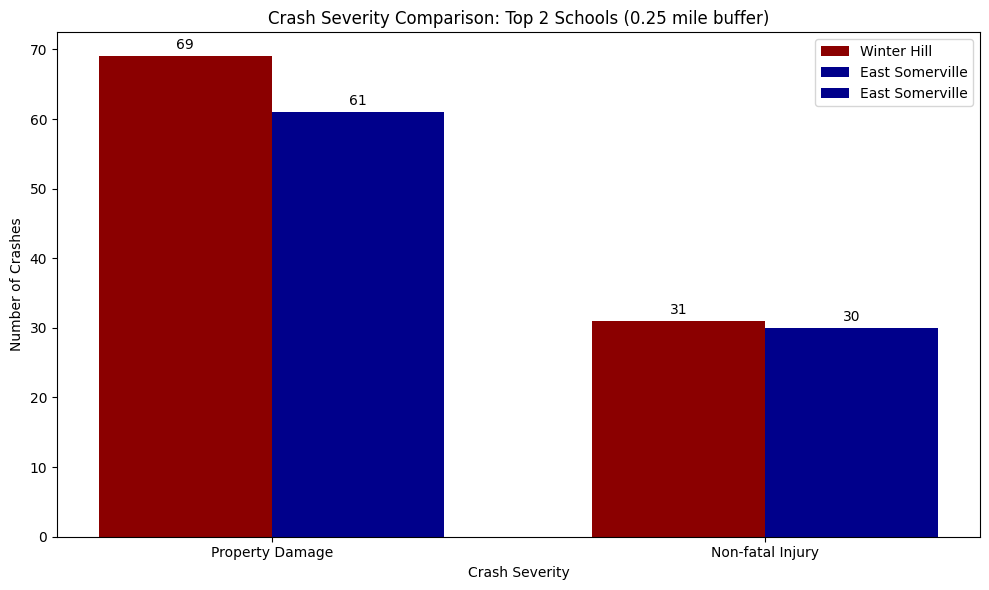

In [195]:
# Cell 8: Visual comparison of top schools (0.25 mile)
# Prepare data for plotting
if 'Crash_Severity' in crashes_in_025.columns:
    
    # Get severity distribution for top schools
    top_schools_list = ['Winter Hill Community Innovation School', 
                        'East Somerville Community School',
                        'Albert F. Argenziano School']
    
    # Filter data
    top_data_025 = crashes_in_025[crashes_in_025['school_name'].isin(top_schools_list)]
    
    # Severity categories
    severity_categories = ['Property damage only (none injured)', 'Non-fatal injury']
    
    # Count for each school
    winter_hill_counts_025 = [
        len(top_data_025[(top_data_025['school_name'] == top_schools_list[0]) & 
                     (top_data_025['Crash_Severity'] == severity_categories[0])]),
        len(top_data_025[(top_data_025['school_name'] == top_schools_list[0]) & 
                     (top_data_025['Crash_Severity'] == severity_categories[1])])
    ]
    
    east_somerville_counts_025 = [
        len(top_data_025[(top_data_025['school_name'] == top_schools_list[1]) & 
                     (top_data_025['Crash_Severity'] == severity_categories[0])]),
        len(top_data_025[(top_data_025['school_name'] == top_schools_list[1]) & 
                     (top_data_025['Crash_Severity'] == severity_categories[1])])
    ]
    
    # Set up plot
    x = np.arange(len(severity_categories))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, winter_hill_counts_025, width, label='Winter Hill', color='darkred')
    bars2 = ax.bar(x + width/2, east_somerville_counts_025, width, label='East Somerville', color='darkblue')
    bars2 = ax.bar(x + width/2, east_somerville_counts_025, width, label='East Somerville', color='darkblue')
    
    # Customize
    ax.set_xlabel('Crash Severity')
    ax.set_ylabel('Number of Crashes')
    ax.set_title('Crash Severity Comparison: Top 2 Schools (0.25 mile buffer)')
    ax.set_xticks(x)
    ax.set_xticklabels(['Property Damage', 'Non-fatal Injury'])
    ax.legend()
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

In [196]:
# Cell 9: Injury severity breakdown for top 3 schools (0.25 mile buffer)
# Using school zone average as baseline (crashes within 0.25mi of any school)

if 'Crash_Severity' in crashes_in_025.columns:
    
    # Top 3 schools based on crash counts
    top_schools_list = [
        'Winter Hill Community Innovation School',
        'East Somerville Community School', 
        'Albert F. Argenziano School'
    ]
    
    top_schools_data_025 = crashes_in_025[crashes_in_025['school_name'].isin(top_schools_list)]
    
    # Create severity breakdown with suffix
    severity_top_025 = pd.crosstab(
        top_schools_data_025['school_name'],
        top_schools_data_025['Crash_Severity']
    )
    
    # Add suffix to column names for clarity
    severity_top_025.columns = [f"{col}_025" for col in severity_top_025.columns]
    
    # Add total column
    severity_top_025['Total_025'] = severity_top_025.sum(axis=1)
    
    # Calculate injury percentage
    injury_cols_025 = [col for col in severity_top_025.columns if 'Non-fatal injury' in col or 'Fatal' in col]
    if injury_cols_025:
        severity_top_025['Injury_Count_025'] = severity_top_025[injury_cols_025].sum(axis=1)
        severity_top_025['Injury_Pct_025'] = (severity_top_025['Injury_Count_025'] / severity_top_025['Total_025'] * 100).round(1)
    
    print("📊 TOP 3 SCHOOLS - CRASH SEVERITY BREAKDOWN (0.25 mile buffer)")
    print("=" * 80)
    print(severity_top_025)
    
    # Calculate SCHOOL ZONE AVERAGE (crashes near ANY school) - Baseline A
    school_zone_avg_025 = (crashes_in_025['Crash_Severity'].str.contains('injury', case=False, na=False).sum() / 
                           len(crashes_in_025)) * 100
    
    print(f"\n📊 SCHOOL ZONE AVERAGE (0.25mi, all 8 schools combined): {school_zone_avg_025:.1f}%")
    
    # Compare each top school to the school zone average
    print("\n📈 Comparison to school zone average:")
    for school in top_schools_list:
        if school in severity_top_025.index:
            school_rate = severity_top_025.loc[school, 'Injury_Pct_025']
            diff = school_rate - school_zone_avg_025
            arrow = "🔺 higher" if diff > 0 else "🔻 lower" if diff < 0 else "➡️ same"
            print(f"   {school}: {school_rate:.1f}% ({arrow} by {abs(diff):.1f}%)")

else:
    print("⚠️  Crash_Severity column not available in joined data")

📊 TOP 3 SCHOOLS - CRASH SEVERITY BREAKDOWN (0.25 mile buffer)
                                         Non-fatal injury_025  \
school_name                                                     
Albert F. Argenziano School                                30   
East Somerville Community School                           30   
Winter Hill Community Innovation School                    31   

                                         Property damage only (none injured)_025  \
school_name                                                                        
Albert F. Argenziano School                                                   44   
East Somerville Community School                                              61   
Winter Hill Community Innovation School                                       69   

                                         Unknown_025  Total_025  \
school_name                                                       
Albert F. Argenziano School                        6     

In [197]:
(crashes_in_025['Crash_Severity'].str.contains('injury', case=False, na=False).sum() / len(crashes_in_025)) * 100

np.float64(32.416502946954814)

### Add in traffic volume data for correlation
This will help us understand exposure—schools near high-traffic roads should expect more crashes simply because more cars are passing through.

In [198]:
# Cell 10: Traffic volume within 0.25 mile of top schools

# Spatial join: traffic counts within school buffers
traffic_in_025 = gpd.sjoin(
    traffic,
    buffer_025,
    how='inner',
    predicate='intersects'
)

print(f"📊 TRAFFIC VOLUME NEAR TOP SCHOOLS (0.25 mile buffer)")
print("=" * 80)

# Focus on top 3 schools
for school in top_schools_list:
    # Get traffic counts near this school
    school_traffic = traffic_in_025[traffic_in_025['school_name'] == school]
    
    if len(school_traffic) > 0 and 'AADT' in school_traffic.columns:
        avg_aadt = school_traffic['AADT'].mean()
        max_aadt = school_traffic['AADT'].max()
        count_locations = len(school_traffic)
        
        print(f"\n🏫 {school}")
        print(f"   Traffic count locations nearby: {count_locations}")
        print(f"   Average AADT: {avg_aadt:,.0f} vehicles/day")
        print(f"   Maximum AADT: {max_aadt:,.0f} vehicles/day")
    else:
        print(f"\n🏫 {school}")
        print(f"   No traffic count data within 0.25mi")

📊 TRAFFIC VOLUME NEAR TOP SCHOOLS (0.25 mile buffer)

🏫 Winter Hill Community Innovation School
   Traffic count locations nearby: 168
   Average AADT: 7,326 vehicles/day
   Maximum AADT: 51,451 vehicles/day

🏫 East Somerville Community School
   Traffic count locations nearby: 176
   Average AADT: 6,602 vehicles/day
   Maximum AADT: 50,545 vehicles/day

🏫 Albert F. Argenziano School
   Traffic count locations nearby: 203
   Average AADT: 7,409 vehicles/day
   Maximum AADT: 22,890 vehicles/day


In [199]:
# Cell 11: Combined priority table (crashes + traffic)

# Get crash totals for all schools
crash_totals = crashes_in_025.groupby('school_name').size().reset_index(name='crashes_025mi')

# Get injury counts for all schools
if 'Crash_Severity' in crashes_in_025.columns:
    injury_counts = crashes_in_025[crashes_in_025['Crash_Severity'].str.contains('injury', case=False, na=False)] \
        .groupby('school_name').size().reset_index(name='injury_crashes_025mi')
else:
    injury_counts = pd.DataFrame({'school_name': crash_totals['school_name'], 'injury_crashes_025mi': 0})

# Get traffic summary for all schools
traffic_summary = traffic_in_025.groupby('school_name').agg(
    traffic_count_locations=('AADT', 'count'),
    avg_aadt=('AADT', 'mean'),
    max_aadt=('AADT', 'max')
).round(0).reset_index()

# Merge everything
priority_table = crash_totals.merge(injury_counts, on='school_name', how='left')
priority_table = priority_table.merge(traffic_summary, on='school_name', how='left')

# Fill NaN values (schools with no traffic data)
priority_table = priority_table.fillna(0)

# Calculate priority score (injuries weighted 3x, crashes 1x, traffic exposure as factor)
priority_table['priority_score'] = (
    priority_table['injury_crashes_025mi'] * 3 +
    (priority_table['crashes_025mi'] - priority_table['injury_crashes_025mi']) * 1
)

# Sort and rank
priority_table = priority_table.sort_values('priority_score', ascending=False)
priority_table['rank'] = range(1, len(priority_table) + 1)

print("🏫 SCHOOL SAFETY PRIORITY RANKING (with traffic context)")
print("=" * 90)
print(priority_table[['rank', 'school_name', 'crashes_025mi', 'injury_crashes_025mi', 
                      'avg_aadt', 'max_aadt', 'priority_score']].to_string(index=False))

🏫 SCHOOL SAFETY PRIORITY RANKING (with traffic context)
 rank                             school_name  crashes_025mi  injury_crashes_025mi  avg_aadt  max_aadt  priority_score
    1 Winter Hill Community Innovation School            100                    31    7326.0     51451             162
    2        East Somerville Community School             91                    30    6602.0     50545             151
    3             Albert F. Argenziano School             80                    30    7409.0     22890             140
    4                  Somerville High School             74                    25    5347.0     20556             124
    5                 Arthur D. Healey School             58                    15    5976.0    156877              88
    6                  John F. Kennedy School             43                    18    5689.0     17686              79
    7     West Somerville Neighborhood School             36                     9    4521.0      9363         

In [200]:
traffic_in_025.head()

,OBJECTID,route_id,from_measure,to_measure,Route_System,Route_Number,Route_Direction,City,County,Hwy_Dist,...,Year_SUT,Year_CT,Length,Record_ID,Source,Shape__Length,SHAPE,geometry,index_right,school_name
7,2643992,I93 NB,20.566400,20.908627,I,93,NB,274,17,4,...,NaN,NaN,0.342227,233699.905295.NW.55.93,B,550.761506,None,"LINESTRING (233893.462 905100.712, 233893.46 9...",1,Arthur D. Healey School
8,2647342,L107021 NB,0.000000,0.064591,L,107021,NB,274,17,4,...,NaN,NaN,0.064591,233965.904291.NE.10.107021,None,103.950081,None,"LINESTRING (233938.435 904247.388, 233969.341 ...",3,East Somerville Community School
8,2647342,L107021 NB,0.000000,0.064591,L,107021,NB,274,17,4,...,NaN,NaN,0.064591,233965.904291.NE.10.107021,None,103.950081,None,"LINESTRING (233938.435 904247.388, 233969.341 ...",7,Winter Hill Community Innovation School
9,2647343,L107021 NB,0.064591,0.087255,L,107021,NB,274,17,4,...,NaN,NaN,0.022663,234002.904350.NE.36.107021,None,36.473102,None,"LINESTRING (233992.77 904336.002, 234012.169 9...",3,East Somerville Community School
9,2647343,L107021 NB,0.064591,0.087255,L,107021,NB,274,17,4,...,NaN,NaN,0.022663,234002.904350.NE.36.107021,None,36.473102,None,"LINESTRING (233992.77 904336.002, 234012.169 9...",7,Winter Hill Community Innovation School


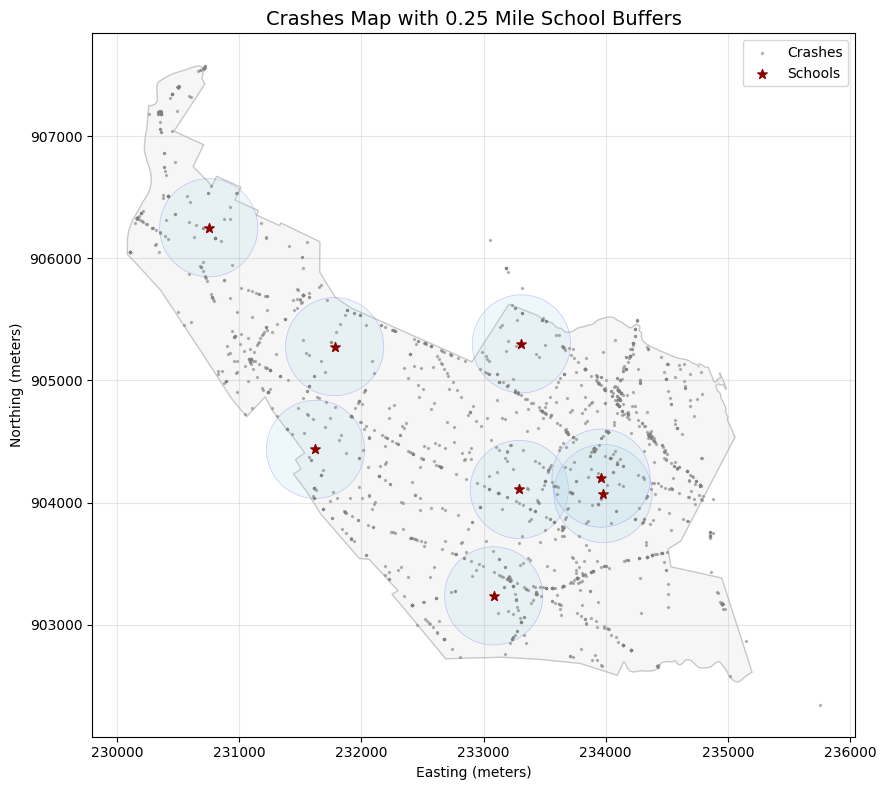

Total crashes plotted: 1722
Crashes within buffers (spatial join result): 509


In [201]:
# Visual check - Crashes with 0.25 mile buffers

fig, ax = plt.subplots(figsize=(10, 8))

# Plot Somerville boundary
boundary.plot(ax=ax, alpha=0.2, color='lightgray', edgecolor='black', linewidth=1)

# Plot school buffers
buffer_025.plot(ax=ax, alpha=0.2, color='lightblue', edgecolor='blue', linewidth=0.5)

# Plot crashes
crashes.plot(ax=ax, markersize=2, color='grey', alpha=0.5, label='Crashes')

# Plot schools for reference
schools.plot(ax=ax, markersize=50, color='darkred', marker='*', label='Schools')

ax.set_title('Crashes Map with 0.25 Mile School Buffers', fontsize=14)
ax.legend()
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total crashes plotted: {len(crashes)}")
print(f"Crashes within buffers (spatial join result): {len(crashes_in_025)}")

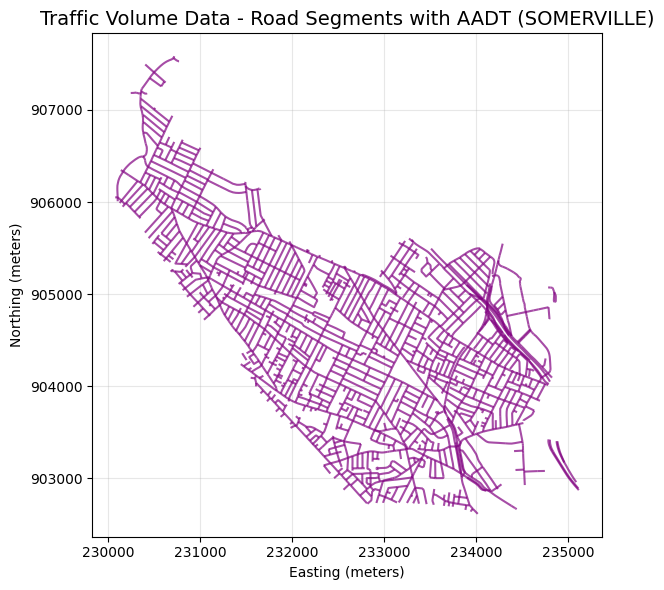

Total traffic features: 2731
Geometry types: LineString    2718
Name: count, dtype: int64
AADT range: 739 - 172,550


In [202]:
# Visualize traffic volume data by itself

fig, ax = plt.subplots(figsize=(8, 6))

# Plot just the traffic lines
if len(traffic) > 0:
    traffic.plot(ax=ax, linewidth=1.5, color='purple', alpha=0.7)
    ax.set_title('Traffic Volume Data - Road Segments with AADT (SOMERVILLE)', fontsize=14)
else:
    ax.text(0.5, 0.5, 'No traffic data loaded', transform=ax.transAxes, fontsize=14, color='red')

# Add some context with a light gray background
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total traffic features: {len(traffic)}")
print(f"Geometry types: {traffic.geometry.type.value_counts()}")
print(f"AADT range: {traffic['AADT'].min():,.0f} - {traffic['AADT'].max():,.0f}")

In [203]:
 # Cell 12: Aggregate traffic exposure by school

print(f"Total traffic-buffer intersections: {len(traffic_in_025)}")

# Calculate traffic exposure per school
school_traffic_exposure_025mi = traffic_in_025.groupby('school_name').agg({
    'AADT': ['count', 'mean', 'max', 'sum']
}).round(0)

# Flatten column names
school_traffic_exposure_025mi.columns = ['segment_count', 'avg_aadt', 'max_aadt', 'total_aadt']
school_traffic_exposure_025mi = school_traffic_exposure_025mi.reset_index()

print("\n📊 TRAFFIC EXPOSURE BY SCHOOL (0.25 mile buffer)")
print("=" * 70)
print(school_traffic_exposure_025mi.to_string(index=False))

# Merge with crash data
if 'priority_table' in locals():
    priority_table = priority_table.merge(
        school_traffic_exposure_025mi,
        on='school_name',
        how='left'
    ).fillna(0)

Total traffic-buffer intersections: 1282

📊 TRAFFIC EXPOSURE BY SCHOOL (0.25 mile buffer)
                            school_name  segment_count  avg_aadt  max_aadt  total_aadt
            Albert F. Argenziano School            203    7409.0     22890     1503997
                Arthur D. Healey School             92    5976.0    156877      549837
               Benjamin G. Brown School            155    3766.0     13118      583794
       East Somerville Community School            176    6602.0     50545     1161980
                 John F. Kennedy School            163    5689.0     17686      927332
                 Somerville High School            164    5347.0     20556      876907
    West Somerville Neighborhood School            161    4521.0      9363      727821
Winter Hill Community Innovation School            168    7326.0     51451     1230836


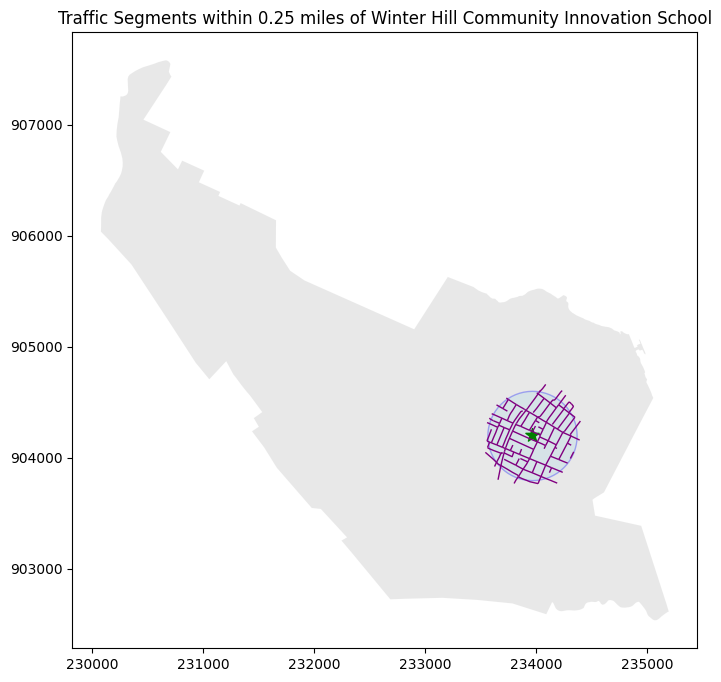

Traffic segments intersecting this buffer (Winter Hill Community Innovation School): 168


In [204]:
# Test: Visualize one school's traffic intersections
test_school = 'Winter Hill Community Innovation School'
test_buffer = buffer_025[buffer_025['school_name'] == test_school].geometry.iloc[0]
test_traffic = traffic[traffic.intersects(test_buffer)]

fig, ax = plt.subplots(figsize=(10, 8))
boundary.plot(ax=ax, alpha=0.5, color='lightgray')
gpd.GeoSeries([test_buffer]).plot(ax=ax, alpha=0.3, color='lightblue', edgecolor='blue')
test_traffic.plot(ax=ax, linewidth=1, color='purple')
schools[schools['school_name'] == test_school].plot(ax=ax, markersize=100, color='green', marker='*')

ax.set_title(f'Traffic Segments within 0.25 miles of {test_school}')
plt.show()

print(f"Traffic segments intersecting this buffer (Winter Hill Community Innovation School): {len(test_traffic)}")

In [205]:
display(school_crash_counts_025mi)

,school_name,crashes_025mi
0,Winter Hill Community Innovation School,100
1,East Somerville Community School,91
2,Albert F. Argenziano School,80
3,Somerville High School,74
4,Arthur D. Healey School,58
5,John F. Kennedy School,43
6,West Somerville Neighborhood School,36
7,Benjamin G. Brown School,27


In [206]:
school_traffic_exposure_025mi

,school_name,segment_count,avg_aadt,max_aadt,total_aadt
0,Albert F. Argenziano School,203,7409.0,22890,1503997
1,Arthur D. Healey School,92,5976.0,156877,549837
2,Benjamin G. Brown School,155,3766.0,13118,583794
3,East Somerville Community School,176,6602.0,50545,1161980
4,John F. Kennedy School,163,5689.0,17686,927332
5,Somerville High School,164,5347.0,20556,876907
6,West Somerville Neighborhood School,161,4521.0,9363,727821
7,Winter Hill Community Innovation School,168,7326.0,51451,1230836


In [207]:
# Cell 13: Combine crash and traffic for final priority ranking
# Use the aggregated crash counts per school

# Now merge with traffic data
priority_final = school_crash_counts_025mi.merge(
    school_traffic_exposure_025mi,
    on='school_name',
    how='left'
)

# Calculate crash rate per 10,000 AADT (normalized for exposure)
priority_final['crashes_per_10k_aadt'] = (
    priority_final['crashes_025mi'] / (priority_final['total_aadt'] / 10000)
).round(2)

# Composite priority score (crashes × traffic exposure)
priority_final['priority_score'] = (
    priority_final['crashes_025mi'] * 2 +  # Crash count weight
    (priority_final['total_aadt'] / 100000) * 1  # Traffic exposure weight
).round(0)

# Sort and rank
priority_final = priority_final.sort_values('priority_score', ascending=False)
priority_final['rank'] = range(1, len(priority_final) + 1)

print("\n🏫 FINAL SCHOOL SAFETY PRIORITY RANKING")
print("=" * 90)
display_cols = ['rank', 'school_name', 'crashes_025mi', 'total_aadt', 
                'crashes_per_10k_aadt', 'priority_score']
print(priority_final[display_cols].to_string(index=False))
display(priority_final)


🏫 FINAL SCHOOL SAFETY PRIORITY RANKING
 rank                             school_name  crashes_025mi  total_aadt  crashes_per_10k_aadt  priority_score
    1 Winter Hill Community Innovation School            100     1230836                  0.81           212.0
    2        East Somerville Community School             91     1161980                  0.78           194.0
    3             Albert F. Argenziano School             80     1503997                  0.53           175.0
    4                  Somerville High School             74      876907                  0.84           157.0
    5                 Arthur D. Healey School             58      549837                  1.05           121.0
    6                  John F. Kennedy School             43      927332                  0.46            95.0
    7     West Somerville Neighborhood School             36      727821                  0.49            79.0
    8                Benjamin G. Brown School             27      583794

,school_name,crashes_025mi,segment_count,avg_aadt,max_aadt,total_aadt,crashes_per_10k_aadt,priority_score,rank
0,Winter Hill Community Innovation School,100,168,7326.0,51451,1230836,0.81,212.0,1
1,East Somerville Community School,91,176,6602.0,50545,1161980,0.78,194.0,2
2,Albert F. Argenziano School,80,203,7409.0,22890,1503997,0.53,175.0,3
3,Somerville High School,74,164,5347.0,20556,876907,0.84,157.0,4
4,Arthur D. Healey School,58,92,5976.0,156877,549837,1.05,121.0,5
5,John F. Kennedy School,43,163,5689.0,17686,927332,0.46,95.0,6
6,West Somerville Neighborhood School,36,161,4521.0,9363,727821,0.49,79.0,7
7,Benjamin G. Brown School,27,155,3766.0,13118,583794,0.46,60.0,8


### Visualizations

In [208]:
# Cell 14: Merge priority scores with school geometries
# Ensure both are in the same CRS
schools_priority_ranks = schools.merge(
    priority_final[['school_name', 'priority_score', 'crashes_025mi', 'avg_aadt','total_aadt', 'crashes_per_10k_aadt', 'rank']],
    on='school_name',
    how='left'
)

print("✅ Schools now have priority attributes")
print(schools_priority_ranks[['school_name', 'rank', 'priority_score']].head())

# Create a color map for priority scores
cmap = plt.cm.RdYlGn_r  # Red (high) to Green (low) reversed
norm = plt.Normalize(vmin=priority_final['priority_score'].min(), 
                     vmax=priority_final['priority_score'].max())

print(f"Priority score range: {priority_final['priority_score'].min()} - {priority_final['priority_score'].max()}")

✅ Schools now have priority attributes
                        school_name  rank  priority_score
0            Somerville High School     4           157.0
1           Arthur D. Healey School     5           121.0
2          Benjamin G. Brown School     8            60.0
3  East Somerville Community School     2           194.0
4       Albert F. Argenziano School     3           175.0
Priority score range: 60.0 - 212.0


In [209]:
schools_priority_ranks.head()

,school_name,latitude,longitude,address,confidence,geometry,priority_score,crashes_025mi,avg_aadt,total_aadt,crashes_per_10k_aadt,rank
0,Somerville High School,42.386770,-71.095694,"Somerville High School, 81 Highland Avenue, So...",0,POINT (233292.393 904108.027),157.0,74,5347.0,876907,0.84,4
1,Arthur D. Healey School,42.397499,-71.095418,"5 Meacham Street, Somerville, MA 02145, United...",0,POINT (233309.399 905299.884),121.0,58,5976.0,549837,1.05,5
2,Benjamin G. Brown School,42.397359,-71.113994,"201 Willow Avenue, Somerville, MA 02144, Unite...",0,POINT (231780.132 905277.243),60.0,27,3766.0,583794,0.46,8
3,East Somerville Community School,42.386437,-71.087368,"50 Cross Street, Somerville, MA 02145, United ...",0,POINT (233978.089 904074.412),194.0,91,6602.0,1161980,0.78,2
4,Albert F. Argenziano School,42.378928,-71.098294,"290 Washington Street, Somerville, MA 02143, U...",0,POINT (233082.409 903236.028),175.0,80,7409.0,1503997,0.53,3


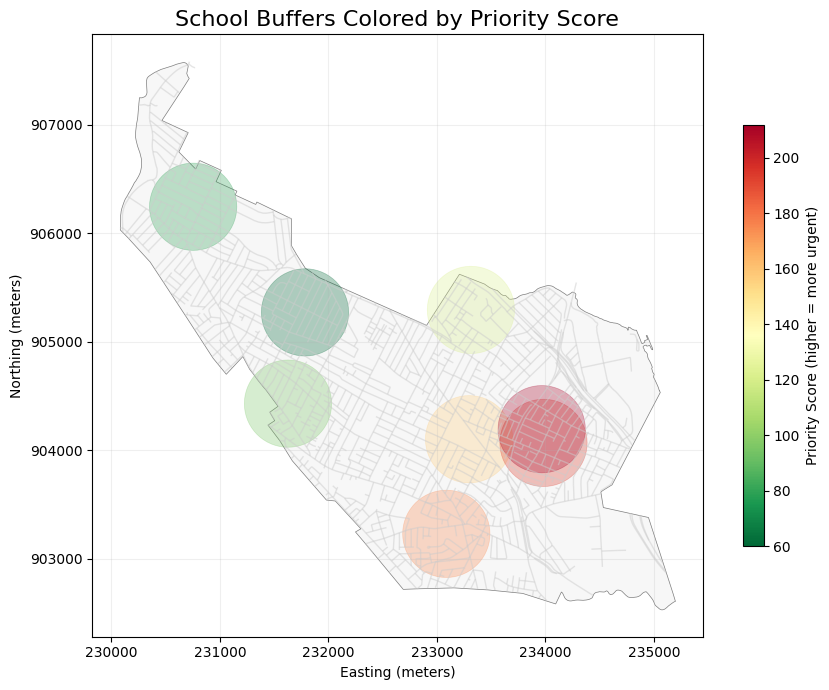

In [210]:
# Cell 14.4: Add school buffers colored by priority
fig, ax = plt.subplots(figsize=(9, 7))

# Plot Somerville boundary
boundary.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=0.5, alpha=0.5)

# Plot traffic segments (light gray, background)
traffic.plot(ax=ax, linewidth=1, color="#cccccc", alpha=0.5)

# Plot buffers colored by priority score
for idx, row in schools_priority_ranks.iterrows():
    school_buffer = buffer_025[buffer_025['school_name'] == row['school_name']]
    if len(school_buffer) > 0:
        color = cmap(norm(row['priority_score']))
        school_buffer.plot(
            ax=ax, 
            color=color, 
            alpha=0.3, 
            edgecolor=color, 
            linewidth=0.5
        )

# Add a colorbar to explain the colors
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label('Priority Score (higher = more urgent)')

ax.set_title('School Buffers Colored by Priority Score', fontsize=16)
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

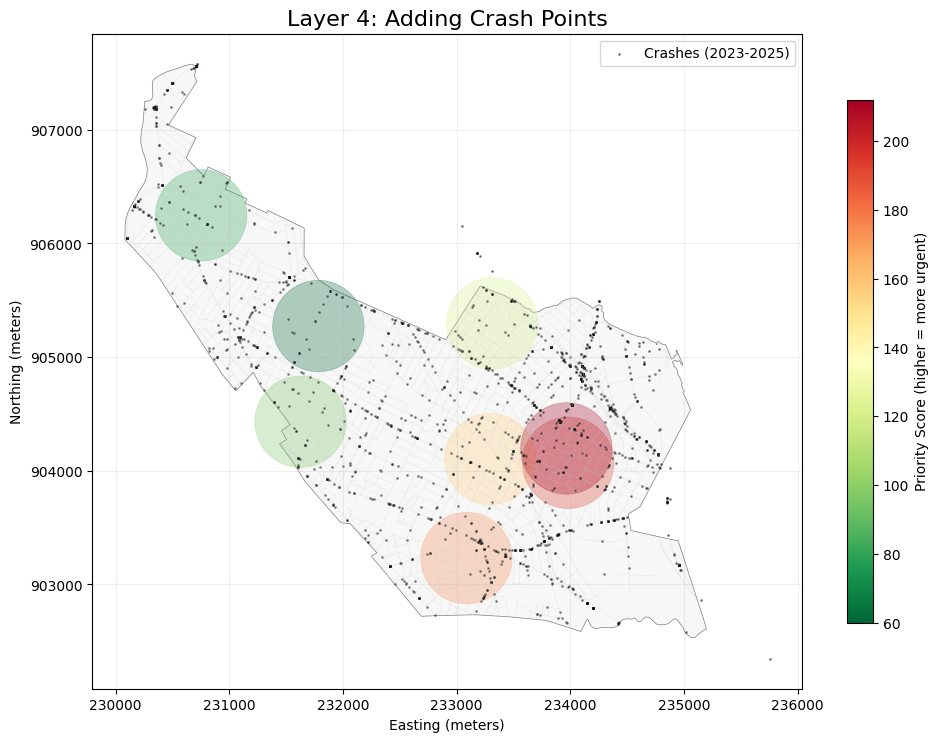

In [211]:
# Cell 14.5: Add crash points
fig, ax = plt.subplots(figsize=(10, 8))

# Plot Somerville boundary
boundary.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=0.5, alpha=0.5)

# Plot traffic segments (light gray, background)
traffic.plot(ax=ax, linewidth=0.5, color='#cccccc', alpha=0.3)

# Plot buffers colored by priority score
for idx, row in schools_priority_ranks.iterrows():
    school_buffer = buffer_025[buffer_025['school_name'] == row['school_name']]
    if len(school_buffer) > 0:
        color = cmap(norm(row['priority_score']))
        school_buffer.plot(
            ax=ax, 
            color=color, 
            alpha=0.3, 
            edgecolor=color, 
            linewidth=0.5
        )

# Plot crash points (small, semi-transparent)
crashes.plot(ax=ax, markersize=1, color='black', alpha=0.4, label='Crashes (2023-2025)')

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label('Priority Score (higher = more urgent)')

ax.set_title('Layer 4: Adding Crash Points', fontsize=16)
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.grid(True, alpha=0.2)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

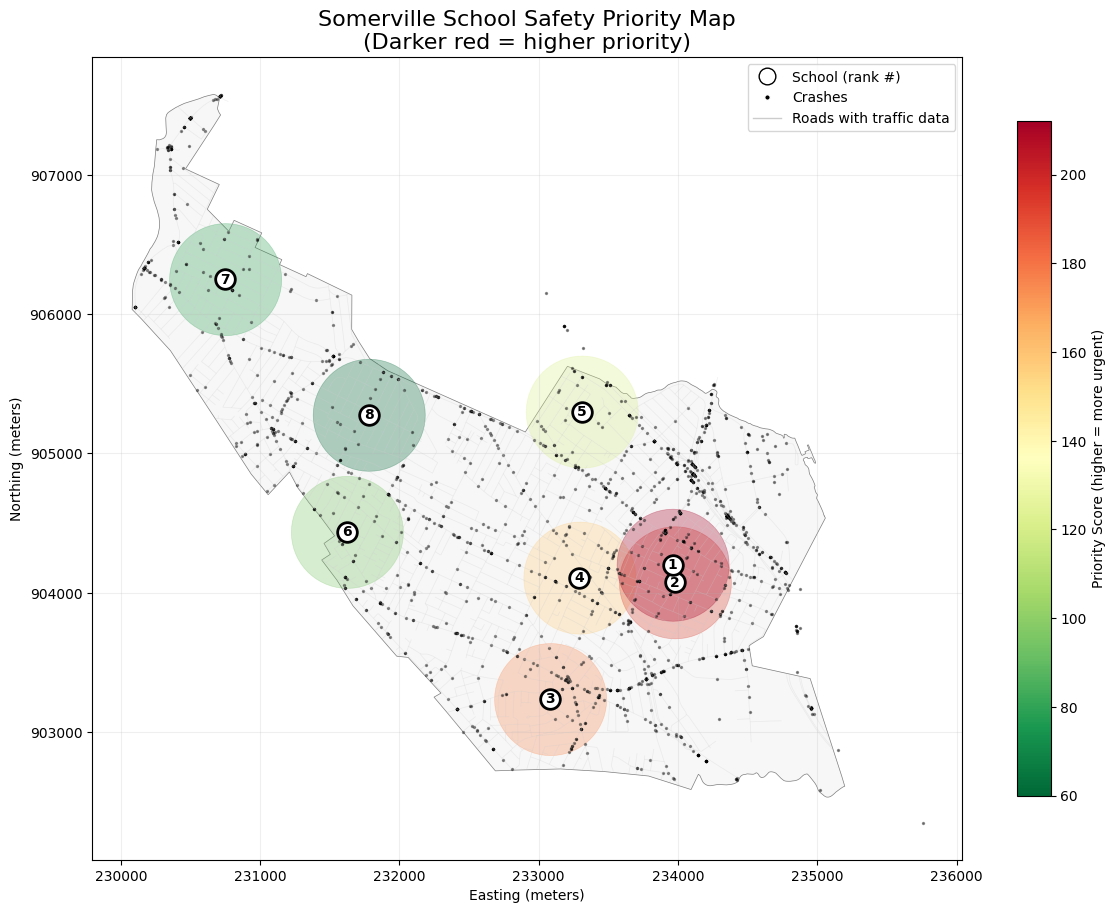

In [212]:
# Cell 14.6: Add school points with rank labels - FINAL MAP
fig, ax = plt.subplots(figsize=(12, 10))

# Plot Somerville boundary
boundary.plot(ax=ax, color='#f0f0f0', edgecolor='black', linewidth=0.5, alpha=0.5)

# Plot traffic segments (light gray, background)
traffic.plot(ax=ax, linewidth=0.5, color='#cccccc', alpha=0.3)

# Plot buffers colored by priority score
for idx, row in schools_priority_ranks.iterrows():
    school_buffer = buffer_025[buffer_025['school_name'] == row['school_name']]
    if len(school_buffer) > 0:
        color = cmap(norm(row['priority_score']))
        school_buffer.plot(
            ax=ax, 
            color=color, 
            alpha=0.3, 
            edgecolor=color, 
            linewidth=0.5
        )

# Plot crash points
crashes.plot(ax=ax, markersize=2, color='black', alpha=0.4, label='Crashes (2023-2025)')

# Plot schools with rank labels
for idx, row in schools_priority_ranks.iterrows():
    # Plot school point
    ax.scatter(
        row.geometry.x, 
        row.geometry.y,
        s=200, 
        c='white',
        edgecolor='black',
        linewidth=2,
        zorder=5
    )
    # Add rank number inside
    ax.annotate(
        str(int(row['rank'])),
        (row.geometry.x, row.geometry.y),
        fontsize=10,
        fontweight='bold',
        ha='center',
        va='center',
        zorder=6
    )

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.7)
cbar.set_label('Priority Score (higher = more urgent)')

# Create custom legend for school points
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='white', 
           markeredgecolor='black', markersize=12, label='School (rank #)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', 
           markersize=4, alpha=1, label='Crashes'),
    Line2D([0], [0], color='#cccccc', linewidth=1, alpha=1, label='Roads with traffic data')
]
ax.legend(handles=legend_elements, loc='upper right')

ax.set_title('Somerville School Safety Priority Map\n(Darker red = higher priority)', fontsize=16)
ax.set_xlabel('Easting (meters)')
ax.set_ylabel('Northing (meters)')
ax.grid(True, alpha=0.2)

plt.tight_layout()

# Save final map
#plt.savefig('../outputs/somerville_school_priority_final.png', dpi=300, bbox_inches='tight')
plt.show()

In [213]:
crashes.shape

(1722, 26)

In [214]:
priority_final

,school_name,crashes_025mi,segment_count,avg_aadt,max_aadt,total_aadt,crashes_per_10k_aadt,priority_score,rank
0,Winter Hill Community Innovation School,100,168,7326.0,51451,1230836,0.81,212.0,1
1,East Somerville Community School,91,176,6602.0,50545,1161980,0.78,194.0,2
2,Albert F. Argenziano School,80,203,7409.0,22890,1503997,0.53,175.0,3
3,Somerville High School,74,164,5347.0,20556,876907,0.84,157.0,4
4,Arthur D. Healey School,58,92,5976.0,156877,549837,1.05,121.0,5
5,John F. Kennedy School,43,163,5689.0,17686,927332,0.46,95.0,6
6,West Somerville Neighborhood School,36,161,4521.0,9363,727821,0.49,79.0,7
7,Benjamin G. Brown School,27,155,3766.0,13118,583794,0.46,60.0,8


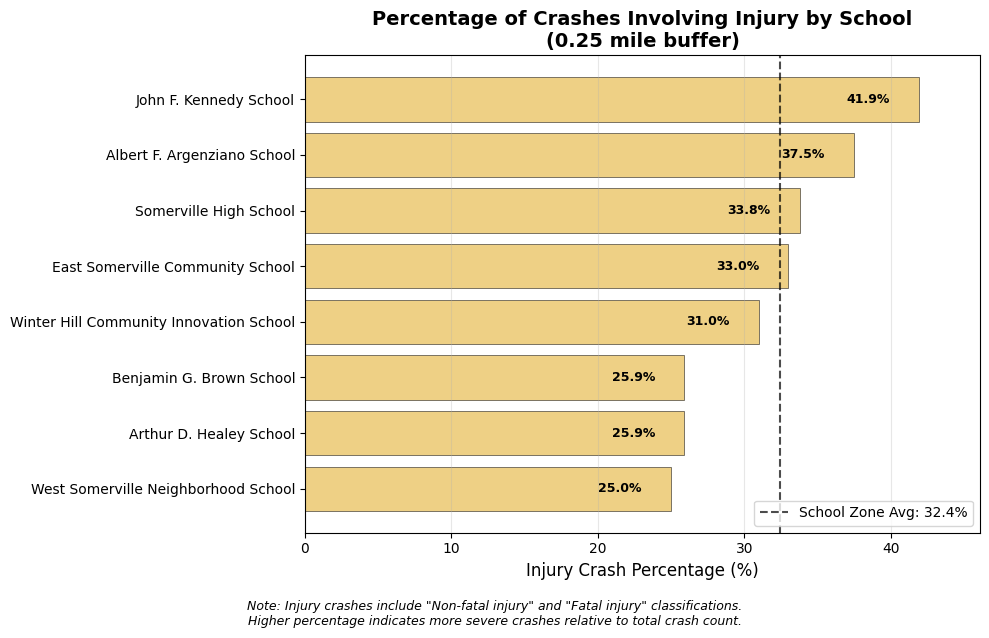

In [215]:
# Cell 15.1: Injury Rate Comparison Bar Chart

# Prepare injury rate data from our severity breakdown

injury_counts = crashes_in_025[crashes_in_025['Crash_Severity'].str.contains('injury', case=False, na=False)] \
    .groupby('school_name').size().reset_index(name='injury_crashes')

# Merge with priority_final
priority_final = priority_final.merge(
    injury_counts, 
    on='school_name', 
    how='left'
).fillna(0)

priority_final['injury_pct'] = (priority_final['injury_crashes'] / priority_final['crashes_025mi'] * 100).round(1)

# Sort by injury rate for better visualization
injury_chart_data = priority_final.sort_values('injury_pct', ascending=True)

# Create figure
fig, ax = plt.subplots(figsize=(10, 6))

# Horizontal bar chart
bars = ax.barh(
    injury_chart_data['school_name'],
    injury_chart_data['injury_pct'],
    color="#e7bd52",  # Red color for injury
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# Add value labels INSIDE the bars at the right end
for i, (bar, pct) in enumerate(zip(bars, injury_chart_data['injury_pct'])):
    # Calculate label position (inside bar, near the end)
    label_x = bar.get_width() - 2  # 2% from the right edge
    # If bar is too small, place label at end but ensure visibility
    if bar.get_width() < 5:
        label_x = bar.get_width() - 0.5
    
    ax.text(
        label_x,  # Position inside the bar
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center',
        ha='right',  # Right-align text so it reads from inside
        fontsize=9,
        fontweight='bold',
        color='black' # White text on dark bars
    )

# Add vertical line for citywide average (if available)
if 'school_zone_avg_025' in locals() or 'school_zone_avg_025' in globals():
    ax.axvline(
        x=school_zone_avg_025, 
        color='black', 
        linestyle='--', 
        linewidth=1.5,
        alpha=0.7,
        label=f'School Zone Avg: {school_zone_avg_025:.1f}%'
    )
    ax.legend(loc='lower right')

# Customize
ax.set_xlabel('Injury Crash Percentage (%)', fontsize=12)
ax.set_ylabel('')
ax.set_title('Percentage of Crashes Involving Injury by School\n(0.25 mile buffer)', fontsize=14, fontweight='bold')
ax.grid(True, axis='x', alpha=0.3)

# Set x-axis limit to give some breathing room
max_pct = injury_chart_data['injury_pct'].max()
ax.set_xlim(0, max_pct * 1.1)

# Add a note about data context
plt.figtext(
    0.5, -0.05,
    'Note: Injury crashes include "Non-fatal injury" and "Fatal injury" classifications.\n'
    'Higher percentage indicates more severe crashes relative to total crash count.',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('../outputs/injury_rate_among_schools.png', dpi=300, bbox_inches='tight')
plt.show()


In [216]:
print(crashes.shape)
total_crashes = crashes.copy()
print(total_crashes.shape)

(1722, 26)
(1722, 26)


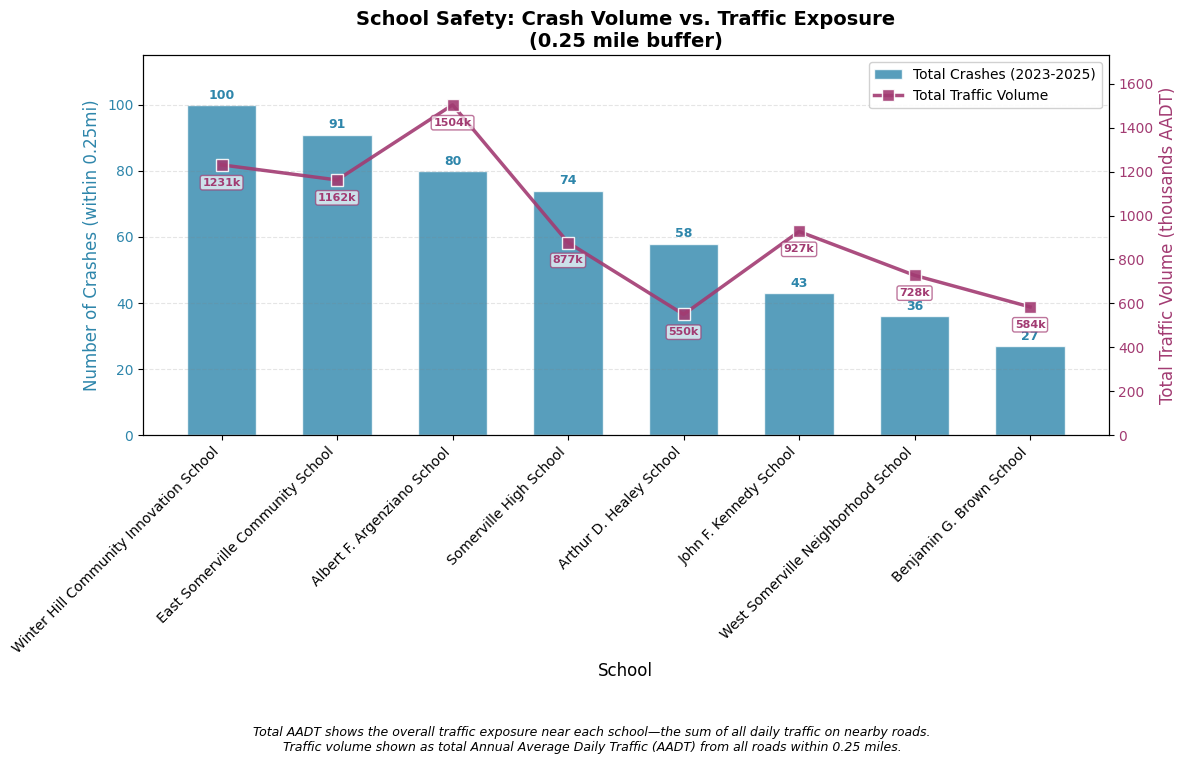

In [217]:
# Cell 15.2: Crash + Traffic Combo Chart

# Prepare data sorted by priority for consistent ordering
combo_data = priority_final.sort_values('priority_score', ascending=False).copy()

# Convert total_aadt to thousands for readability
combo_data['total_aadt_thousands'] = combo_data['total_aadt'] / 1000

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# Color palette (more harmonious)
crash_color = '#2E86AB'  # Soft blue
traffic_color = '#A23B72'  # Muted purple
highlight_color = '#F18F01'  # Warm orange for accents

# Bar chart for crashes (primary axis)
x_pos = np.arange(len(combo_data))
width = 0.6

bars = ax1.bar(
    x_pos, 
    combo_data['crashes_025mi'],
    width,
    color=crash_color,
    alpha=0.8,
    edgecolor='white',
    linewidth=1,
    label='Total Crashes (2023-2025)'
)

# Customize primary axis
ax1.set_xlabel('School', fontsize=12)
ax1.set_ylabel('Number of Crashes (within 0.25mi)', fontsize=12, color=crash_color)
ax1.tick_params(axis='y', labelcolor=crash_color)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(combo_data['school_name'], rotation=45, ha='right', fontsize=10)
ax1.grid(True, axis='y', alpha=0.2, linestyle='--', color='gray')

# Set y-axis to start at 0
ax1.set_ylim(0, max(combo_data['crashes_025mi']) * 1.15)

# Create secondary axis for traffic
ax2 = ax1.twinx()

# Line plot for traffic (secondary axis)
line = ax2.plot(
    x_pos,
    combo_data['total_aadt_thousands'],
    color=traffic_color,
    marker='s',  # Square markers for distinction
    linewidth=2.5,
    markersize=8,
    label='Total Traffic Volume',
    alpha=0.9,
    markeredgecolor='white',
    markeredgewidth=1
)

# Customize secondary axis
ax2.set_ylabel('Total Traffic Volume (thousands AADT)', fontsize=12, color=traffic_color)
ax2.tick_params(axis='y', labelcolor=traffic_color)
ax2.set_ylim(0, max(combo_data['total_aadt_thousands']) * 1.15)

# Add value labels on bars
for i, (bar, crashes) in enumerate(zip(bars, combo_data['crashes_025mi'])):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        crashes + 1,
        str(int(crashes)),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=crash_color
    )

# Add traffic value labels
for i, (x, traffic_val) in enumerate(zip(x_pos, combo_data['total_aadt_thousands'])):
    ax2.annotate(
        f'{traffic_val:.0f}k',
        (x, traffic_val),
        xytext=(0, -15),  # Offset below the point
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color=traffic_color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=traffic_color)
    )

# Title and legend
ax1.set_title('School Safety: Crash Volume vs. Traffic Exposure\n(0.25 mile buffer)', fontsize=14, fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)


# Add annotation explaining the relationship
plt.figtext(
    0.5, -0.08,
    'Total AADT shows the overall traffic exposure near each school—the sum of all daily traffic on nearby roads.\n'
    'Traffic volume shown as total Annual Average Daily Traffic (AADT) from all roads within 0.25 miles.',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('../outputs/crashes_vs_traffic_total_aadt.png', dpi=300, bbox_inches='tight')
plt.show()

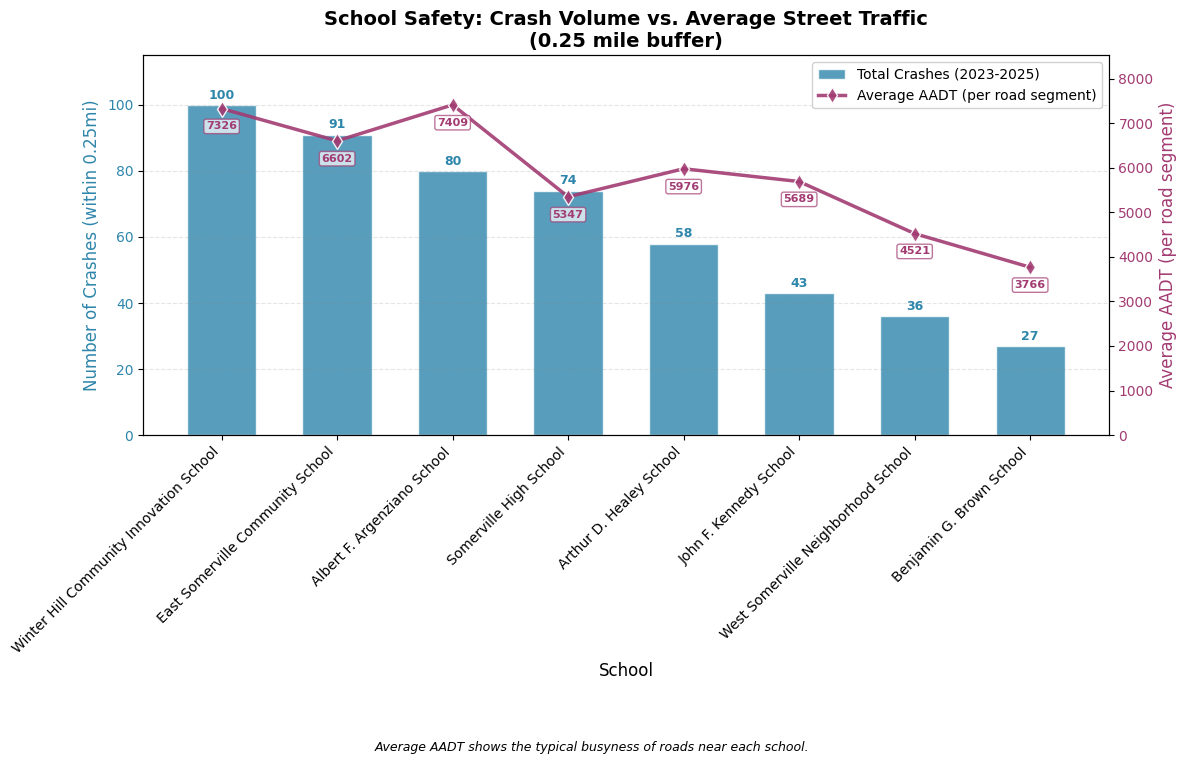

In [218]:
# Cell 15.3: Crash + Average AADT Combo Chart

# Prepare data sorted by priority for consistent ordering
combo_data = priority_final.sort_values('priority_score', ascending=False).copy()

# Create figure and primary axis
fig, ax1 = plt.subplots(figsize=(12, 7))

# Color palette (keeping consistent with previous)
crash_color = '#2E86AB'  # Soft blue
traffic_color = '#A23B72'  # Muted purple
highlight_color = '#F18F01'  # Warm orange for accents

# Bar chart for crashes (primary axis)
x_pos = np.arange(len(combo_data))
width = 0.6

bars = ax1.bar(
    x_pos, 
    combo_data['crashes_025mi'],
    width,
    color=crash_color,
    alpha=0.8,
    edgecolor='white',
    linewidth=1,
    label='Total Crashes (2023-2025)'
)

# Customize primary axis
ax1.set_xlabel('School', fontsize=12)
ax1.set_ylabel('Number of Crashes (within 0.25mi)', fontsize=12, color=crash_color)
ax1.tick_params(axis='y', labelcolor=crash_color)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(combo_data['school_name'], rotation=45, ha='right', fontsize=10)
ax1.grid(True, axis='y', alpha=0.2, linestyle='--', color='gray')

# Set y-axis to start at 0
ax1.set_ylim(0, max(combo_data['crashes_025mi']) * 1.15)

# Create secondary axis for average AADT
ax2 = ax1.twinx()

# Line plot for average AADT (secondary axis)
line = ax2.plot(
    x_pos,
    combo_data['avg_aadt'],  # Using avg_aadt from traffic_by_school
    color=traffic_color,
    marker='d',  # Diamond markers to distinguish from total AADT version
    linewidth=2.5,
    markersize=8,
    label='Average AADT (per road segment)',
    alpha=0.9,
    markeredgecolor='white',
    markeredgewidth=1
)

# Customize secondary axis
ax2.set_ylabel('Average AADT (per road segment)', fontsize=12, color=traffic_color)
ax2.tick_params(axis='y', labelcolor=traffic_color)
ax2.set_ylim(0, max(combo_data['avg_aadt']) * 1.15)

# Add value labels on bars
for i, (bar, crashes) in enumerate(zip(bars, combo_data['crashes_025mi'])):
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        crashes + 1,
        str(int(crashes)),
        ha='center',
        va='bottom',
        fontsize=9,
        fontweight='bold',
        color=crash_color
    )

# Add average AADT value labels
for i, (x, avg_val) in enumerate(zip(x_pos, combo_data['avg_aadt'])):
    ax2.annotate(
        f'{avg_val:.0f}',
        (x, avg_val),
        xytext=(0, -15),  # Offset below the point
        textcoords='offset points',
        ha='center',
        fontsize=8,
        color=traffic_color,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7, edgecolor=traffic_color)
    )

# Title and legend
ax1.set_title('School Safety: Crash Volume vs. Average Street Traffic\n(0.25 mile buffer)', fontsize=14, fontweight='bold')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', framealpha=0.9)


# Add annotation explaining the difference
plt.figtext(
    0.5, -0.08,
    'Average AADT shows the typical busyness of roads near each school.',
    ha='center', fontsize=9, style='italic'
)

plt.tight_layout()
plt.savefig('../outputs/crashes_vs_avg_aadt.png', dpi=300, bbox_inches='tight')
plt.show()

#### Prep interactive web map 

In [219]:
buffer_025

,school_name,geometry
0,Somerville High School,"POLYGON ((233694.728 904108.027, 233692.79 904..."
1,Arthur D. Healey School,"POLYGON ((233711.734 905299.884, 233709.796 90..."
2,Benjamin G. Brown School,"POLYGON ((232182.467 905277.243, 232180.53 905..."
3,East Somerville Community School,"POLYGON ((234380.424 904074.412, 234378.487 90..."
4,Albert F. Argenziano School,"POLYGON ((233484.744 903236.028, 233482.807 90..."
5,John F. Kennedy School,"POLYGON ((232025.558 904436.357, 232023.621 90..."
6,West Somerville Neighborhood School,"POLYGON ((231151.295 906250.945, 231149.358 90..."
7,Winter Hill Community Innovation School,"POLYGON ((234364.127 904200.574, 234362.19 904..."


In [220]:
# Cell 16: Set pojections for web mapping

# Ensure all data is in WGS84 (EPSG:4326) for web mapping
# Leafmap/MapLibre expects geographic coordinates
boundary_wgs84 = boundary.to_crs('EPSG:4326')
traffic_wgs84 = traffic.to_crs('EPSG:4326')
total_crashes_wgs84 = total_crashes.to_crs('EPSG:4326')
buffers_025_priority = buffer_025.to_crs('EPSG:4326')

# Merge priority data with school geometries
schools_priority_ranks_wgs84 = schools_priority_ranks.to_crs('EPSG:4326').copy()

# Prepare buffer data with priority scores
buffers_025_priority_wgs84 = buffers_025_priority.merge(
    schools_priority_ranks_wgs84[['school_name', 'rank', 'priority_score', 'crashes_025mi', 'avg_aadt', 'total_aadt']],
    on='school_name',
    how='left'
)

# Add formatted display columns BEFORE converting to GeoJSON
buffers_025_priority_wgs84['display_rank'] = 'Rank: #' + buffers_025_priority_wgs84['rank'].astype(str)
buffers_025_priority_wgs84['display_crashes'] = 'Crashes: ' + buffers_025_priority_wgs84['crashes_025mi'].astype(str)
buffers_025_priority_wgs84['display_score'] = 'Priority Score: ' + buffers_025_priority_wgs84['priority_score'].round(0).astype(str)
buffers_025_priority_wgs84['display_traffic'] = 'Traffic: ' + (buffers_025_priority_wgs84['total_aadt']/1000).round(0).astype(str) + 'k AADT'

print("✅ Data prepared for interactive map")
print(f"Buffers: {len(buffers_025_priority_wgs84)}")
print(f"Schools: {len(schools_priority_ranks_wgs84)}")
print(f"Crashes: {len(total_crashes_wgs84)}")
display(buffers_025_priority_wgs84.head())

✅ Data prepared for interactive map
Buffers: 8
Schools: 8
Crashes: 1722


,school_name,geometry,rank,priority_score,crashes_025mi,avg_aadt,total_aadt,display_rank,display_crashes,display_score,display_traffic
0,Somerville High School,"POLYGON ((-71.09081 42.38675, -71.09083 42.386...",4,157.0,74,5347.0,876907,Rank: #4,Crashes: 74,Priority Score: 157.0,Traffic: 877.0k AADT
1,Arthur D. Healey School,"POLYGON ((-71.09053 42.39748, -71.09056 42.397...",5,121.0,58,5976.0,549837,Rank: #5,Crashes: 58,Priority Score: 121.0,Traffic: 550.0k AADT
2,Benjamin G. Brown School,"POLYGON ((-71.10911 42.39734, -71.10913 42.396...",8,60.0,27,3766.0,583794,Rank: #8,Crashes: 27,Priority Score: 60.0,Traffic: 584.0k AADT
3,East Somerville Community School,"POLYGON ((-71.08248 42.38642, -71.08251 42.386...",2,194.0,91,6602.0,1161980,Rank: #2,Crashes: 91,Priority Score: 194.0,Traffic: 1162.0k AADT
4,Albert F. Argenziano School,"POLYGON ((-71.09341 42.37891, -71.09343 42.378...",3,175.0,80,7409.0,1503997,Rank: #3,Crashes: 80,Priority Score: 175.0,Traffic: 1504.0k AADT


In [221]:
# Cell 2: Define color and style functions

# Calculate min/max for color scaling (using your data)
min_score = buffers_025_priority_wgs84['priority_score'].min()
max_score = buffers_025_priority_wgs84['priority_score'].max()
mid_score = (min_score + max_score) / 2

print(f"Color scale: Green ({min_score:.0f}) → Yellow ({mid_score:.0f}) → Red ({max_score:.0f})")

# Function to get color based on priority score (Green → Yellow → Red)
def get_buffer_color(score):
    norm = (score - min_score) / (max_score - min_score)
    
    # Three-stop interpolation: Green (0,255,0) → Yellow (255,255,0) → Red (255,0,0)
    if norm <= 0.5:
        # Green to Yellow segment
        local_norm = norm * 2  # Scale 0-0.5 to 0-1
        r = int(255 * local_norm)
        g = 255
        b = 0
    else:
        # Yellow to Red segment
        local_norm = (norm - 0.5) * 2  # Scale 0.5-1 to 0-1
        r = 255
        g = int(255 * (1 - local_norm))
        b = 0
    
    return f'#{r:02x}{g:02x}{b:02x}'

# Style callback for GeoJSON
def style_callback(feature):
    return {
        'color': 'black',
        'weight': 1,
        'fillColor': feature['properties']['fill_color'],
        'fillOpacity': 0.3
    }

print("✅ Color functions defined")

Color scale: Green (60) → Yellow (136) → Red (212)
✅ Color functions defined


In [222]:
# Cell 3: Define hover callback (needs hover_info widget, defined in next cell)
# We'll define the function body later after hover_info exists
# For now, create a placeholder
hover_callback = None

In [223]:
# Cell 4: Initialize map and hover info panel

# Create map centered on Somerville
m = Map(
    center=(42.3875, -71.0995),
    zoom=13,
    basemap=basemaps.CartoDB.Positron
)

# Create HTML widget for hover info
hover_info = widgets.HTML(
    value="""
    <div style="
        background: white;
        padding: 10px;
        border-radius: 5px;
        box-shadow: 0 0 10px rgba(0,0,0,0.3);
        font-family: Arial, sans-serif;
        font-size: 12px;
        min-width: 250px;
        border-left: 4px solid #E39414;
    ">
        <h4 style="margin: 0 0 8px 0; color: #333;">School Safety Info</h4>
        <p style="margin: 0; color: #666; font-style: italic;">Hover over a buffer to see details</p>
    </div>
    """,
    layout=widgets.Layout(width='300px')
)

# Add widget to map
info_control = WidgetControl(widget=hover_info, position='bottomleft')
m.add(info_control)

print("✅ Map and hover widget initialized")

✅ Map and hover widget initialized


In [224]:
# Cell 5: Define hover and mouseout handlers

def on_buffer_hover(event=None, feature=None, **kwargs):
    """Handle mouseover events - show tooltip."""
    if feature and 'properties' in feature:
        props = feature['properties']
        
        school_name = props.get('school_name', 'Unknown School')
        priority_score = props.get('priority_score', 'N/A')
        rank = props.get('rank', 'N/A')
        crashes = props.get('crashes_025mi', 'N/A')
        total_aadt = props.get('total_aadt', 'N/A')
        
        if isinstance(total_aadt, (int, float)):
            total_aadt = f"{total_aadt:,.0f}"
        
        fill_color = props.get('fill_color', '#E39414')
        
        hover_info.value = f"""
        <div style="
            background: white;
            padding: 10px;
            border-radius: 5px;
            box-shadow: 0 0 10px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif;
            font-size: 12px;
            min-width: 250px;
            border-left: 4px solid {fill_color};
        ">
            <h4 style="margin: 0 0 8px 0; color: #333;">{school_name}</h4>
            <table style="width: 100%; border-collapse: collapse;">
                <tr><td><b>Rank:</b></td><td style="text-align: right;">#{rank}</td></tr>
                <tr><td><b>Crashes (0.25mi):</b></td><td style="text-align: right;">{crashes}</td></tr>
                <tr><td><b>Traffic (AADT):</b></td><td style="text-align: right;">{total_aadt}</td></tr>
                <tr><td><b>Priority Score:</b></td><td style="text-align: right;">{priority_score}</td></tr>
            </table>
        </div>
        """
        
        # Ensure the control is on the map (in case it was removed)
        if info_control not in m.controls:
            m.add(info_control)


def on_buffer_msg(_, content, buffers):
    """Handle all messages, including mouseout events."""
    event_type = content.get('type', '')
    if event_type == 'mouseout':
        # Reset to default message
        hover_info.value = """
        <div style="
            background: white;
            padding: 10px;
            border-radius: 5px;
            box-shadow: 0 0 10px rgba(0,0,0,0.3);
            font-family: Arial, sans-serif;
            font-size: 12px;
            min-width: 250px;
            border-left: 4px solid #E39414;
        ">
            <h4 style="margin: 0 0 8px 0; color: #333;">School Traffic Safety Info</h4>
            <p style="margin: 0; color: #666; font-style: italic;">Hover over a buffer to see details</p>
        </div>
        """
        
print("✅ Hover callback defined")

✅ Hover callback defined


In [225]:
# Cell 6: Prepare buffer data with colors

# Add color column to the GeoDataFrame
buffers_025_priority_wgs84['fill_color'] = buffers_025_priority_wgs84['priority_score'].apply(get_buffer_color)

# Convert to GeoJSON
buffers_geojson = json.loads(buffers_025_priority_wgs84.to_json())

print(f"✅ Prepared {len(buffers_025_priority_wgs84)} buffers with colors")

✅ Prepared 8 buffers with colors


In [226]:
# Cell 7: Add Somerville boundary
boundary_geojson = json.loads(boundary_wgs84.to_json())

boundary_layer = GeoJSON(
    data=boundary_geojson,
    name="Somerville Boundary",
    style={
        'color': '#E39414',
        'weight': 3,
        'opacity': 0.5,
        'fill': False
    }
)

In [227]:
# Cell 8: Add crashes
crashes_geo = GeoData(
    geo_dataframe=total_crashes_wgs84,
    style={'color': 'none', 'radius': 2, 'fillColor': '#3366cc', 
           'opacity': 1, 'weight': 1.9, 'fillOpacity': 0.4},
    point_style={'radius': 5, 'color': 'red', 'fillOpacity': 0.8, 
                 'fillColor': 'blue', 'weight': 3},
    name='Crashes'
)


In [228]:
# Cell 9: Add buffers layer with hover and mouseout

# Create GeoJSON layer
buffers_layer = GeoJSON(
    data=buffers_geojson,
    style={
        'opacity': 1,
        'fillOpacity': 0.2,
        'weight': 0
    },
    hover_style={
        'color': 'white',
        'fillOpacity': 0.3,
        'weight': 2
    },
    style_callback=style_callback
)

# Register hover (mouseover) callback
buffers_layer.on_hover(on_buffer_hover)

# Register message listener for mouseout and other events
buffers_layer.on_msg(on_buffer_msg)

In [229]:
# Cell 10: Add all layers

m.add(boundary_layer)


m.add(crashes_geo)


m.add(buffers_layer)

_ = None

#### Render Interactive map

In [230]:
m

Map(center=[42.3875, -71.0995], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'z…